In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error

import os
import itertools
import warnings
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

# **Data Preview**

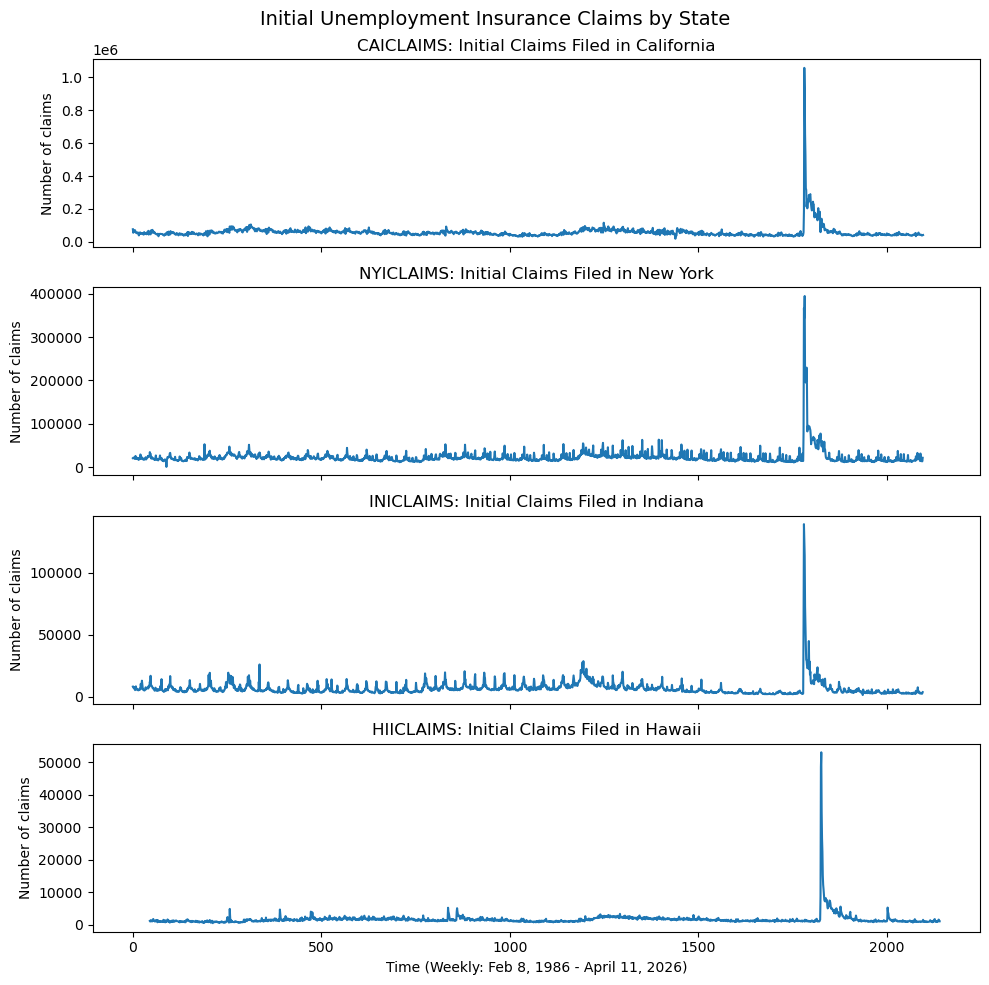

In [2]:
datasets = ["CAICLAIMS", "NYICLAIMS", "INICLAIMS", "HIICLAIMS"]
state_names = {
    "CAICLAIMS": "California",
    "NYICLAIMS": "New York",
    "INICLAIMS": "Indiana",
    "HIICLAIMS": "Hawaii"
}

claims_dfs = {}

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

for ax, code in zip(axes, datasets):
    df = pd.read_csv(f"Data/{code}.csv")
    df.rename(columns={code: "Claims"}, inplace=True)
    
    claims_dfs[code] = df
    globals()[code] = df
    
    ax.plot(df["Claims"])
    ax.set_title(f"{code}: Initial Claims Filed in {state_names[code]}")
    ax.set_ylabel("Number of claims")

axes[-1].set_xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
fig.suptitle("Initial Unemployment Insurance Claims by State", fontsize=14)
plt.tight_layout()
plt.show();

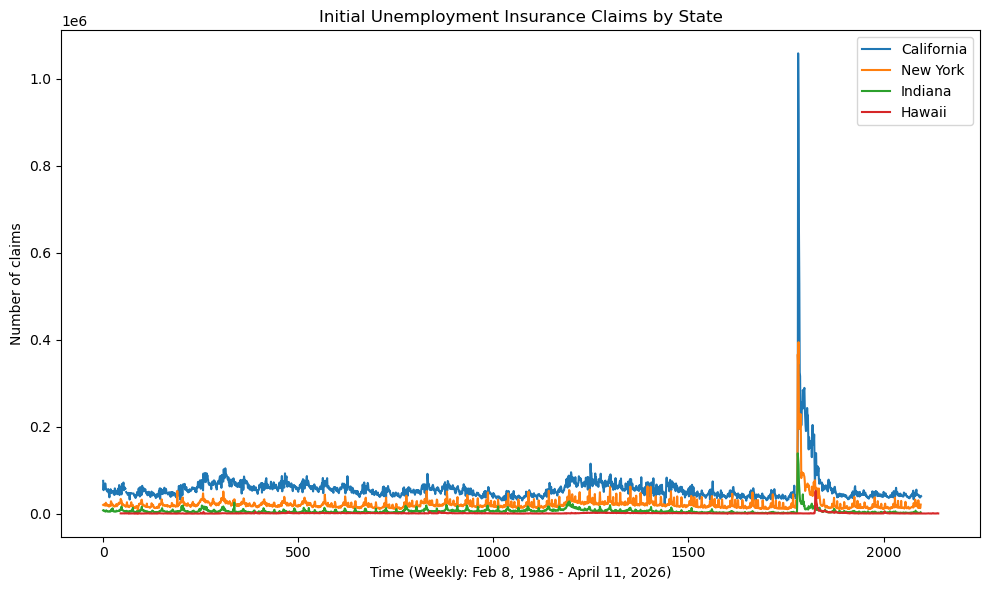

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

for code in datasets:
    df = claims_dfs[code]
    ax.plot(df["Claims"], label=state_names[code])

ax.set_xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
ax.set_ylabel("Number of claims")
ax.set_title("Initial Unemployment Insurance Claims by State")
ax.legend()
plt.tight_layout()
plt.show();

# **CAICLAIMS Model Testing**

## **1. ARIMA Baseline Model**

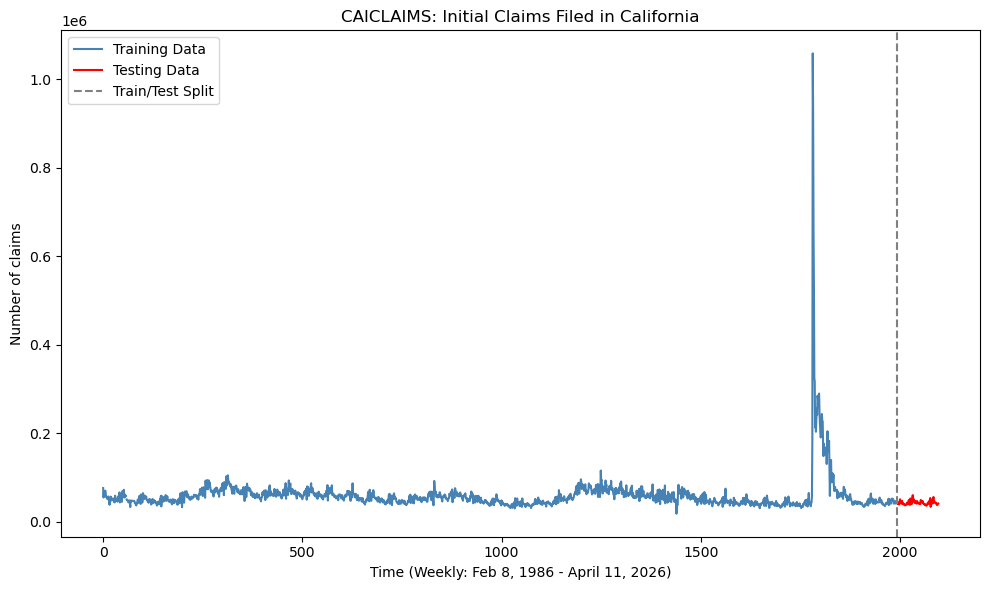

In [4]:
y_CA = claims_dfs["CAICLAIMS"]["Claims"]

test_horizon = 104  # final 2 years
train_end = len(y_CA) - test_horizon
ttrain = np.arange(train_end)
ttest = np.arange(train_end, len(y_CA))
tpred = np.arange(train_end, len(y_CA) + test_horizon)  # future time points for forecasting, 2 years ahead

ytrain_CA = y_CA.iloc[:train_end]
ytest_CA = y_CA.iloc[train_end:]

plt.figure(figsize=(10, 6))
plt.plot(ttrain, ytrain_CA, label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Testing Data", color="red")
plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.title("CAICLAIMS: Initial Claims Filed in California")
plt.xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

### **Training Data Time Series Analysis**

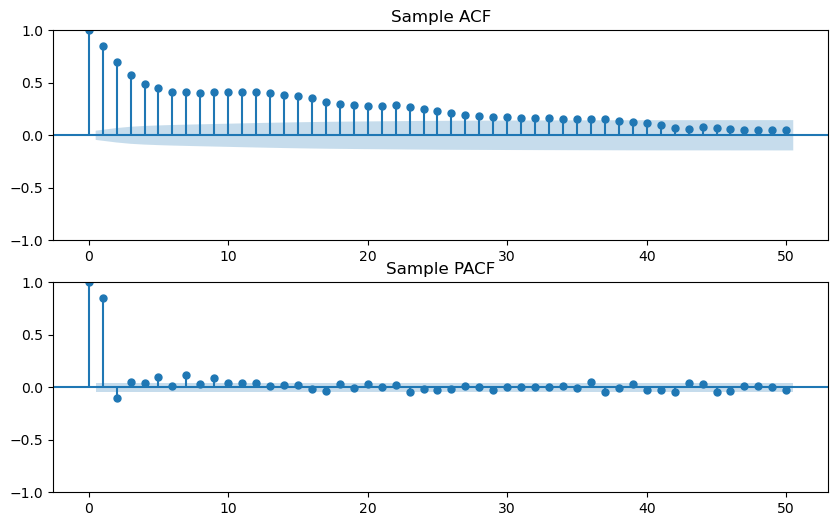

In [5]:
p_max = 50
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(ytrain_CA.dropna(), lags=p_max, ax=ax1, title="Sample ACF")
plot_pacf(ytrain_CA.dropna(), lags=p_max, ax=ax2, title="Sample PACF")
plt.show();

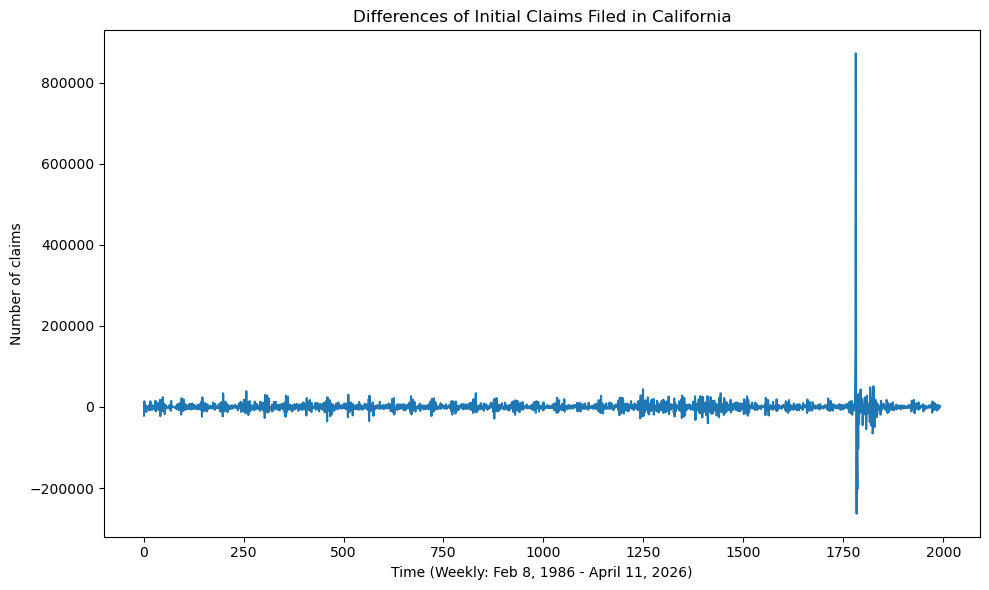

In [6]:
ytrain_CA_diff = ytrain_CA.diff()

plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.title("Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

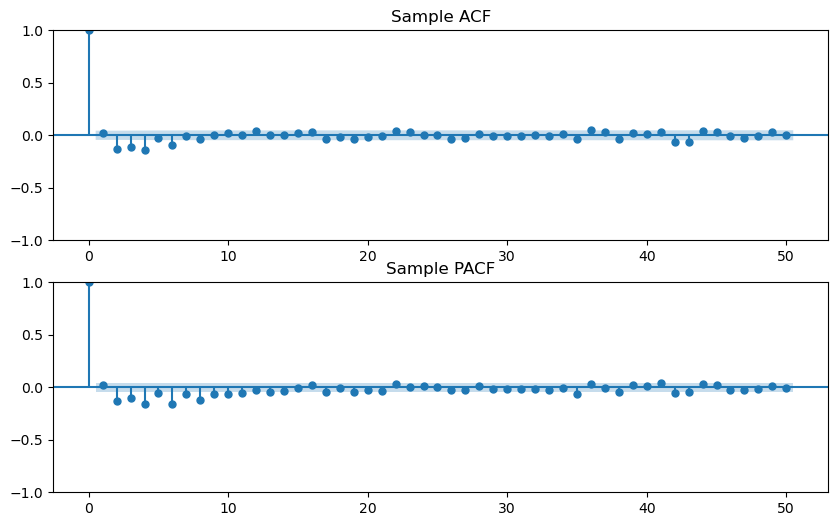

In [7]:
p_max = 50
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(ytrain_CA_diff.dropna(), lags=p_max, ax=ax1, title="Sample ACF")
plot_pacf(ytrain_CA_diff.dropna(), lags=p_max, ax=ax2, title="Sample PACF")
plt.show();

### **Parameter Selection (Grid Search)**

In [8]:
pmax, dmax, qmax = 8, 1, 6

def fit_arima(params):
    warnings.filterwarnings("ignore")
    p, d, q = params
    
    try:
        model = ARIMA(ytrain_CA, order=(p, d, q)).fit()
        forecast = model.get_forecast(steps=len(ytest_CA))
        yhat = forecast.predicted_mean
        yhat.index = ytest_CA.index
        rmse = np.sqrt(mean_squared_error(ytest_CA, yhat))
        
        return {
            "p": p,
            "d": d,
            "q": q,
            "AIC": model.aic,
            "BIC": model.bic,
            "RMSE": rmse
        }
    except Exception:
        return None

In [9]:
cache_path_arima = "arima_grid_results_CAICLAIMS.csv"

param_grid = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

if os.path.exists(cache_path_arima):
    print(f"Loading cached ARIMA grid search results from {cache_path_arima}")
    results_arima_df = pd.read_csv(cache_path_arima)

else:
    print("Running ARIMA grid search...")

    results_arima = Parallel(n_jobs=-1, verbose=10)(
        delayed(fit_arima)(params) for params in param_grid
    )

    results_arima = [r for r in results_arima if r is not None]
    results_arima_df = pd.DataFrame(results_arima)

    if results_arima_df.empty:
        raise ValueError("ARIMA grid search failed: no models were successfully fit.")

    results_arima_df.to_csv(cache_path_arima, index=False)
    print(f"Saved ARIMA grid search results to {cache_path_arima}")

Running ARIMA grid search...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   18.9s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   26.0s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   33.7s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   42.7s
[Parallel(n_jobs=-1)]: Done 124 out of 126 | elapsed:  1.1min remaining:    1.0s


Saved ARIMA grid search results to arima_grid_results_CAICLAIMS.csv


[Parallel(n_jobs=-1)]: Done 126 out of 126 | elapsed:  1.1min finished


### **Best Models by Evaluation Metrics**

In [10]:
best_aic = results_arima_df.loc[results_arima_df["AIC"].idxmin()]
best_bic = results_arima_df.loc[results_arima_df["BIC"].idxmin()]
best_rmse = results_arima_df.loc[results_arima_df["RMSE"].idxmin()]

print(
    f"Best model by AIC: ARIMA({int(best_aic['p'])}, "
    f"{int(best_aic['d'])}, {int(best_aic['q'])}), "
    f"AIC: {best_aic['AIC']:.3f}, ",
    f"BIC: {best_aic['BIC']:.3f}, ",
    f"RMSE: {best_aic['RMSE']:.3f}"
)
print(
    f"Best model by BIC: ARIMA({int(best_bic['p'])}, "
    f"{int(best_bic['d'])}, {int(best_bic['q'])}), "
    f"AIC: {best_bic['AIC']:.3f}, ",
    f"BIC: {best_bic['BIC']:.3f}, ",
    f"RMSE: {best_bic['RMSE']:.3f}"
)
print(
    f"Best model by RMSE: ARIMA({int(best_rmse['p'])}, "
    f"{int(best_rmse['d'])}, {int(best_rmse['q'])}), "
    f"AIC: {best_rmse['AIC']:.3f}, ",
    f"BIC: {best_rmse['BIC']:.3f}, ",
    f"RMSE: {best_rmse['RMSE']:.3f}"
)

Best model by AIC: ARIMA(3, 1, 5), AIC: 45436.385,  BIC: 45486.757,  RMSE: 4804.857
Best model by BIC: ARIMA(0, 1, 6), AIC: 45437.527,  BIC: 45476.705,  RMSE: 4809.158
Best model by RMSE: ARIMA(8, 1, 0), AIC: 45470.097,  BIC: 45520.469,  RMSE: 4598.933


In [11]:
best_aic_model = ARIMA(ytrain_CA, order=(int(best_aic['p']), int(best_aic['d']), int(best_aic['q']))).fit()
print(best_aic_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:                 ARIMA(3, 1, 5)   Log Likelihood              -22709.189
Date:                Tue, 28 Apr 2026   AIC                          45436.378
Time:                        18:01:29   BIC                          45486.750
Sample:                             0   HQIC                         45454.877
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2513      0.063    -19.747      0.000      -1.376      -1.127
ar.L2          0.1546      0.096      1.617      0.106      -0.033       0.342
ar.L3          0.4671      0.053      8.800      0.0

In [12]:
best_bic_model = ARIMA(ytrain_CA, order=(int(best_bic['p']), int(best_bic['d']), int(best_bic['q']))).fit()
print(best_bic_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:                 ARIMA(0, 1, 6)   Log Likelihood              -22711.764
Date:                Tue, 28 Apr 2026   AIC                          45437.527
Time:                        18:01:30   BIC                          45476.705
Sample:                             0   HQIC                         45451.916
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0642      0.005    -13.086      0.000      -0.074      -0.055
ma.L2         -0.2220      0.012    -17.828      0.000      -0.246      -0.198
ma.L3         -0.1540      0.029     -5.404      0.0

In [13]:
best_rmse_model = ARIMA(ytrain_CA, order=(int(best_rmse['p']), int(best_rmse['d']), int(best_rmse['q']))).fit()
print(best_rmse_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:                 ARIMA(8, 1, 0)   Log Likelihood              -22726.049
Date:                Tue, 28 Apr 2026   AIC                          45470.097
Time:                        18:01:31   BIC                          45520.469
Sample:                             0   HQIC                         45488.597
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0423      0.004    -10.263      0.000      -0.050      -0.034
ar.L2         -0.2009      0.010    -20.179      0.000      -0.220      -0.181
ar.L3         -0.1483      0.042     -3.528      0.0

### **Plotted ARIMA Predictions**

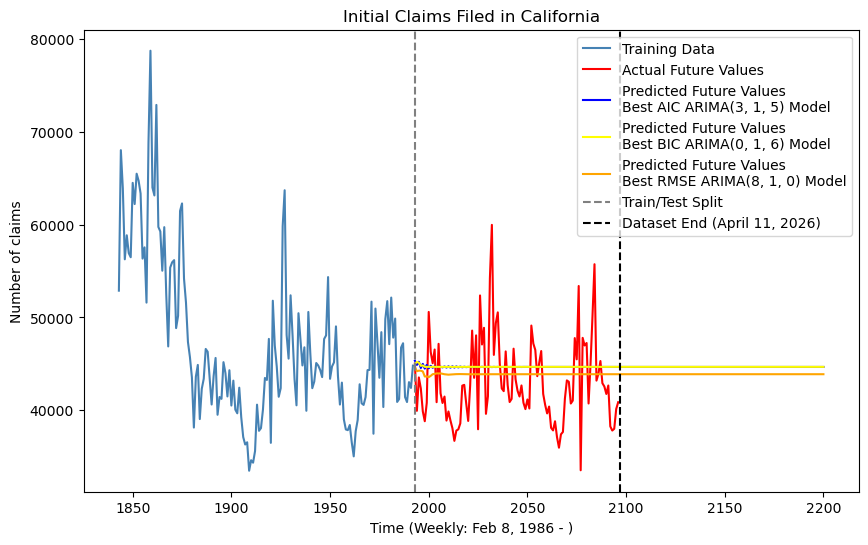

Root Mean Squared Error of Best AIC ARIMA(3, 1, 5) Model: 4804.807622002152
Root Mean Squared Error of Best BIC ARIMA(0, 1, 6) Model: 4809.157796229412
Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4598.93312709685


In [21]:
best_aic_fcast = best_aic_model.get_prediction(start=train_end, end=len(y_CA) + test_horizon - 1)
best_aic_yhat = best_aic_fcast.predicted_mean
best_aic_rmse = np.sqrt(mean_squared_error(ytest_CA, best_aic_yhat.iloc[:len(ytest_CA)]))

best_bic_fcast = best_bic_model.get_prediction(start=train_end, end=len(y_CA) + test_horizon -1)
best_bic_yhat = best_bic_fcast.predicted_mean
best_bic_rmse = np.sqrt(mean_squared_error(ytest_CA, best_bic_yhat.iloc[:len(ytest_CA)]))

best_rmse_fcast = best_rmse_model.get_prediction(start=train_end, end=len(y_CA) + test_horizon - 1)
best_rmse_yhat = best_rmse_fcast.predicted_mean
best_rmse_rmse = np.sqrt(mean_squared_error(ytest_CA, best_rmse_yhat.iloc[:len(ytest_CA)]))


plt.figure(figsize=(10,6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA[(train_end - 150):], color="steelblue", label="Training Data")
plt.plot(ttest, ytest_CA, color="red", label="Actual Future Values")

plt.plot(tpred, best_aic_yhat, color="blue", 
         label=f"Predicted Future Values\nBest AIC ARIMA({best_aic['p']:.0f}, {best_aic['d']:.0f}, {best_aic['q']:.0f}) Model")
plt.plot(tpred, best_bic_yhat, color="yellow", 
         label=f"Predicted Future Values\nBest BIC ARIMA({best_bic['p']:.0f}, {best_bic['d']:.0f}, {best_bic['q']:.0f}) Model")
plt.plot(tpred, best_rmse_yhat, color="orange", 
         label=f"Predicted Future Values\nBest RMSE ARIMA({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model")

plt.axvline(x=train_end, color="grey", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End (April 11, 2026)")

plt.xlabel("Time (Weekly: Feb 8, 1986 - )")
plt.ylabel("Number of claims")
plt.title("Initial Claims Filed in California")
plt.legend(); plt.show();

print(f"Root Mean Squared Error of Best AIC ARIMA({best_aic['p']:.0f}, {best_aic['d']:.0f}, {best_aic['q']:.0f}) Model: {best_aic_rmse}")
print(f"Root Mean Squared Error of Best BIC ARIMA({best_bic['p']:.0f}, {best_bic['d']:.0f}, {best_bic['q']:.0f}) Model: {best_bic_rmse}")
print(f"Root Mean Squared Error of Best RMSE ARIMA({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model: {best_rmse_rmse}")

## **2. SARIMAX with Fourier Frequencies, Before/After COVID Dummy**

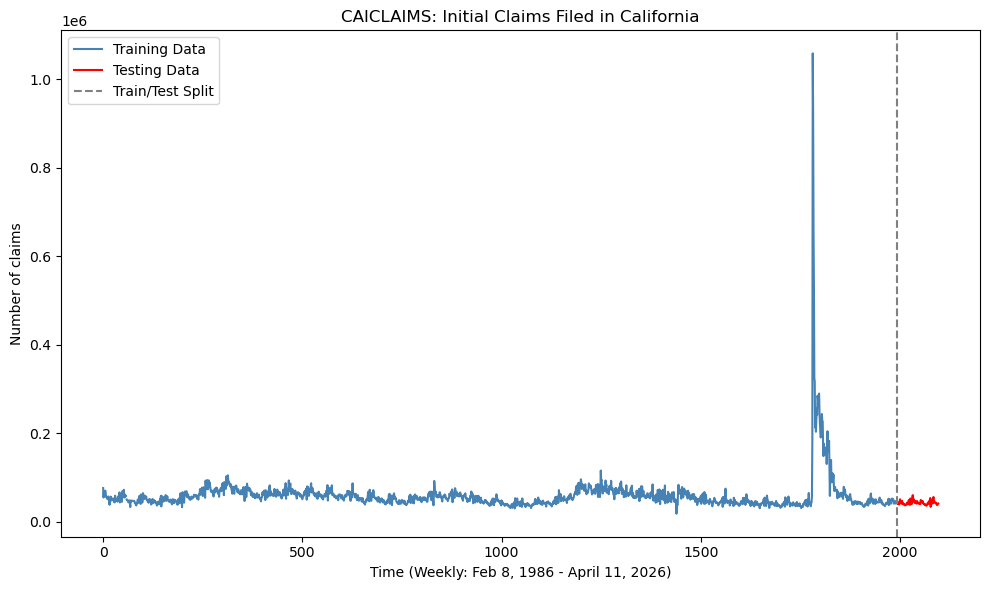

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(ttrain, ytrain_CA, label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Testing Data", color="red")
plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.title("CAICLAIMS: Initial Claims Filed in California")
plt.xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

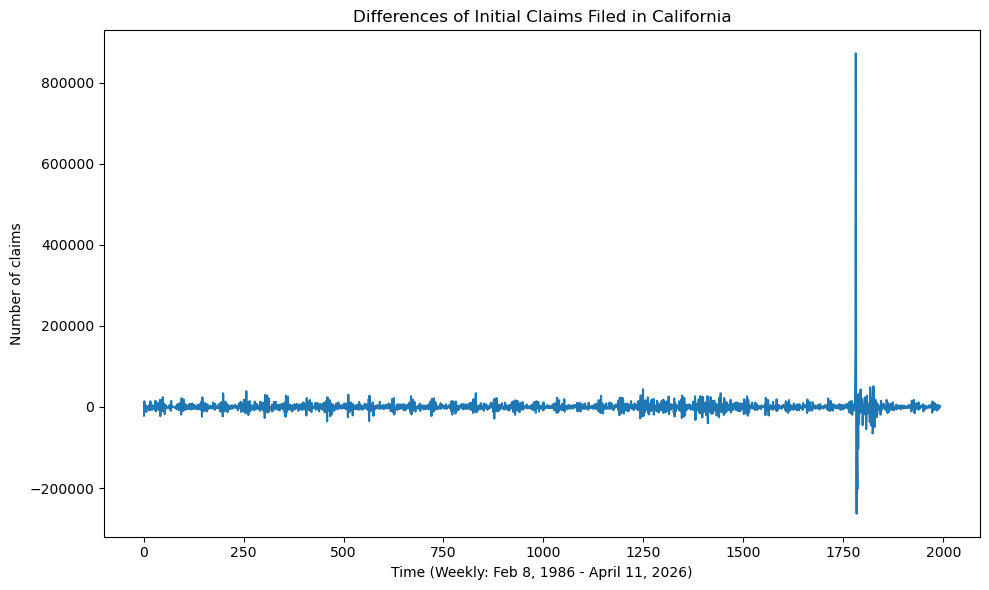

In [16]:
plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.title("Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

### **Design Matrix Construction**

In [17]:
def make_features(n, covid_start=1780):
    t = np.arange(n)
    X = pd.DataFrame(index=np.arange(n))

    # linear trend
    X["trend"] = t

    # yearly seasonality for weekly data
    for k in range(1, 4):  # 1st, 2nd, 3rd harmonic
        X[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)

    # COVID level-shift dummy
    X["covid_after"] = (t >= covid_start).astype(int)

    return X

### **SARIMAX Model Test**

In [18]:
# Exog features through observed data only (for holdout RMSE / grid search)
X_CA = make_features(len(y_CA), covid_start=1780)

Xtrain_CA = X_CA.iloc[:train_end]
Xtest_CA = X_CA.iloc[train_end:]
Xtest_CA = Xtest_CA[Xtrain_CA.columns]

# Exog through observed data + future period (for extended future forecasts)
X_CA_extended = make_features(len(y_CA) + test_horizon, covid_start=1780)

Xtrain_CA_extended = X_CA_extended.iloc[:train_end]
Xtest_CA_extended = X_CA_extended.iloc[train_end : len(y_CA) + test_horizon]
Xtest_CA_extended = Xtest_CA_extended[Xtrain_CA_extended.columns]


# Best RMSE Baseline ARIMA(8, 1, 0) model with exogenous regressors
sarimax_model = SARIMAX(
    ytrain_CA,
    exog=Xtrain_CA_extended,
    order=(best_rmse['p'], best_rmse['d'], best_rmse['q']),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarimax_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:               SARIMAX(8, 1, 0)   Log Likelihood              -22607.734
Date:                Tue, 28 Apr 2026   AIC                          45249.469
Time:                        18:01:44   BIC                          45344.547
Sample:                             0   HQIC                         45284.394
                               - 1993                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
trend         -77.9511    616.206     -0.127      0.899   -1285.693    1129.791
sin_1        2503.6547   7189.390      0.348      0.728   -1.16e+04    1.66e+04
cos_1        3316.2240   7590.046      0.437    

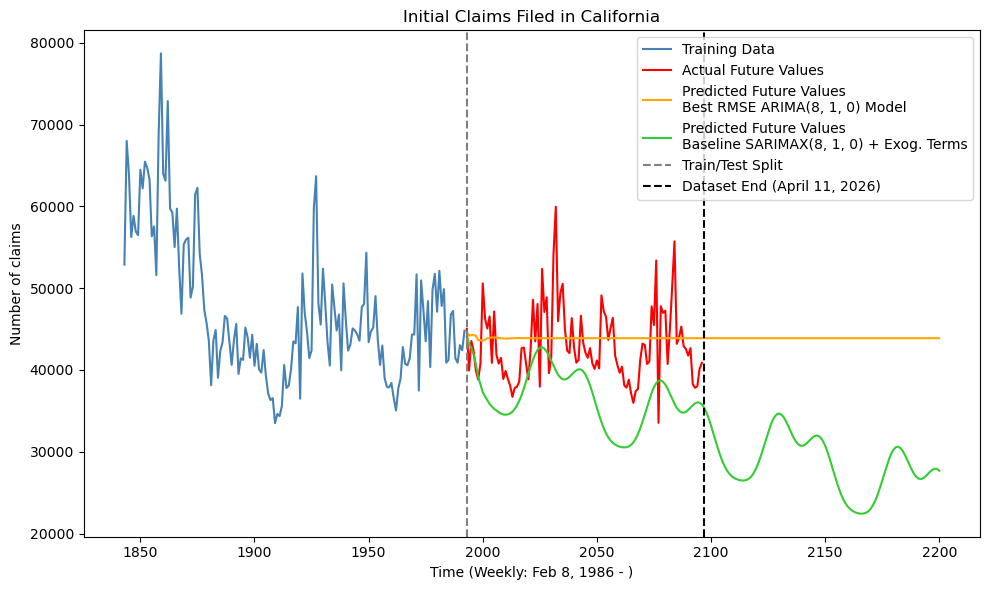

Root Mean Squared Error of Best RMSE ARMIA(8, 1, 0) Model: 4598.93312709685
Room Mean Squared Error of Baseline SARIMAX (8, 1, 0) Model: 7861.362181423878


In [22]:
# Forecast test period
sarimax_fcast = sarimax_model.get_forecast(steps=len(ytest_CA) + test_horizon, exog=Xtest_CA_extended)
sarimax_yhat = sarimax_fcast.predicted_mean
sarimax_yhat.index = tpred
sarimax_rmse = np.sqrt(mean_squared_error(ytest_CA, sarimax_yhat.iloc[:len(ytest_CA)]))


# Plot predictions against ARIMA baselines and actual values
plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Future Values", color="red")

plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Predicted Future Values\nBest RMSE ARIMA({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model")
plt.plot(tpred, sarimax_yhat, color="limegreen",
         label=f"Predicted Future Values\nBaseline SARIMAX({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) + Exog. Terms")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split" )
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End (April 11, 2026)")

plt.title("Initial Claims Filed in California")
plt.xlabel("Time (Weekly: Feb 8, 1986 - )")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();


print(f"Root Mean Squared Error of Best RMSE ARMIA({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model: {best_rmse_rmse}")
print(f"Room Mean Squared Error of Baseline SARIMAX ({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model: {sarimax_rmse}")

### **Parameter Selection (Grid Search)**

In [23]:
pmax, dmax, qmax = 8, 1, 6

def fit_sarimax_exog(params):
    warnings.filterwarnings("ignore")

    p, d, q = params

    try:
        model = SARIMAX(
            ytrain_CA,
            exog=Xtrain_CA,
            order=(p, d, q),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        forecast = model.get_forecast(
            steps=len(ytest_CA),
            exog=Xtest_CA
        )

        y_hat = forecast.predicted_mean
        y_hat.index = ytest_CA.index

        rmse = np.sqrt(mean_squared_error(ytest_CA, y_hat))

        return {
            "p": p,
            "d": d,
            "q": q,
            "AIC": model.aic,
            "BIC": model.bic,
            "RMSE": rmse
        }

    except Exception:
        return None

In [24]:
cache_path_sarimax = "sarimax_grid_results_CAICLAIMS.csv"

param_grid = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

if os.path.exists(cache_path_sarimax):
    print(f"Loading cached SARIMAX grid search results from {cache_path_sarimax}")
    results_sarimax_df = pd.read_csv(cache_path_sarimax)

else:
    print("Running SARIMAX grid search...")

    results_sarimax = Parallel(n_jobs=-1, verbose=10)(
        delayed(fit_sarimax_exog)(params) for params in param_grid
    )

    results_sarimax = [r for r in results_sarimax if r is not None]
    results_sarimax_df = pd.DataFrame(results_sarimax)

    if results_sarimax_df.empty:
        raise ValueError(
            "SARIMAX grid search failed: no models were successfully fit. "
            "Check that len(Xtest_CA) equals len(ytest_CA)."
        )

    results_sarimax_df.to_csv(cache_path_sarimax, index=False)
    print(f"Saved SARIMAX grid search results to {cache_path_sarimax}")

Running SARIMAX grid search...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   14.5s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   26.6s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   37.4s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   51.1s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 124 out of 126 | elapsed:  1.9min remaining:    1.8s


Saved SARIMAX grid search results to sarimax_grid_results_CAICLAIMS.csv


[Parallel(n_jobs=-1)]: Done 126 out of 126 | elapsed:  1.9min finished


### **Best Models by Evaluation Metrics**

In [27]:
best_aic_sarimax = results_sarimax_df.loc[results_sarimax_df["AIC"].idxmin()]
best_bic_sarimax = results_sarimax_df.loc[results_sarimax_df["BIC"].idxmin()]
best_rmse_sarimax = results_sarimax_df.loc[results_sarimax_df["RMSE"].idxmin()]

print(
    f"Best model by AIC: SARIMAX({int(best_aic_sarimax['p'])}, "
    f"{int(best_aic_sarimax['d'])}, {int(best_aic_sarimax['q'])}), "
    f"AIC: {best_aic_sarimax['AIC']:.3f}, "
    f"BIC: {best_aic_sarimax['BIC']:.3f}, "
    f"RMSE: {best_aic_sarimax['RMSE']:.3f}"
)

print(
    f"Best model by BIC: SARIMAX({int(best_bic_sarimax['p'])}, "
    f"{int(best_bic_sarimax['d'])}, {int(best_bic_sarimax['q'])}), "
    f"AIC: {best_bic_sarimax['AIC']:.3f}, "
    f"BIC: {best_bic_sarimax['BIC']:.3f}, "
    f"RMSE: {best_bic_sarimax['RMSE']:.3f}"
)

print(
    f"Best model by RMSE: SARIMAX({int(best_rmse_sarimax['p'])}, "
    f"{int(best_rmse_sarimax['d'])}, {int(best_rmse_sarimax['q'])}), "
    f"AIC: {best_rmse_sarimax['AIC']:.3f}, "
    f"BIC: {best_rmse_sarimax['BIC']:.3f}, "
    f"RMSE: {best_rmse_sarimax['RMSE']:.3f}"
)

Best model by AIC: SARIMAX(8, 1, 1), AIC: 45202.391, BIC: 45303.063, RMSE: 7126.754
Best model by BIC: SARIMAX(8, 1, 1), AIC: 45202.391, BIC: 45303.063, RMSE: 7126.754
Best model by RMSE: SARIMAX(8, 1, 1), AIC: 45202.391, BIC: 45303.063, RMSE: 7126.754


In [28]:
best_p = int(best_rmse_sarimax['p'])
best_d = int(best_rmse_sarimax['d'])
best_q = int(best_rmse_sarimax['q'])

best_rmse_sarimax_model = SARIMAX(
    ytrain_CA,
    exog=Xtrain_CA_extended,
    order=(best_p, best_d, best_q),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(best_rmse_sarimax_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:               SARIMAX(8, 1, 1)   Log Likelihood              -22583.196
Date:                Tue, 28 Apr 2026   AIC                          45202.391
Time:                        18:05:44   BIC                          45303.063
Sample:                             0   HQIC                         45239.371
                               - 1993                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
trend         -77.9511    378.793     -0.206      0.837    -820.372     664.470
sin_1        2503.6547   5032.125      0.498      0.619   -7359.129    1.24e+04
cos_1        3316.2240   5527.934      0.600    

### **Plotted SARIMAX Predictions**

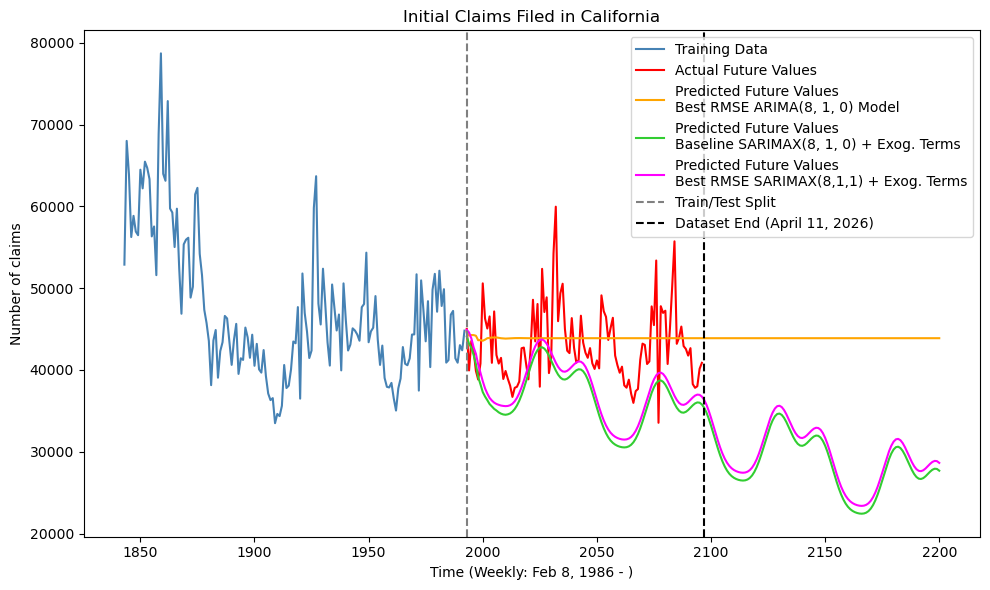

Root Mean Squared Error of Best RMSE ARMIA(8, 1, 0) Model: 4598.93312709685
Room Mean Squared Error of Baseline SARIMAX (8, 1, 0) Model: 7861.362181423878
Root Mean Squared Error of Best RMSE SARIMAX(8, 1, 1) Model: 7126.754229243658


In [30]:
best_rmse_sarimax_fcast = best_rmse_sarimax_model.get_forecast(steps=len(ytest_CA) + test_horizon, exog=Xtest_CA_extended)

best_rmse_sarimax_yhat = best_rmse_sarimax_fcast.predicted_mean
best_rmse_sarimax_yhat.index = tpred
best_sarimax_rmse = np.sqrt(mean_squared_error(ytest_CA, best_rmse_sarimax_yhat.iloc[:len(ytest_CA)]))


plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Future Values", color="red")

plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Predicted Future Values\nBest RMSE ARIMA({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model")
plt.plot(tpred, sarimax_yhat, color="limegreen",
         label=f"Predicted Future Values\nBaseline SARIMAX({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) + Exog. Terms")
plt.plot(tpred, best_rmse_sarimax_yhat, color="magenta",
         label=f"Predicted Future Values\nBest RMSE SARIMAX({best_p},{best_d},{best_q}) + Exog. Terms")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End (April 11, 2026)")

plt.title("Initial Claims Filed in California")
plt.xlabel("Time (Weekly: Feb 8, 1986 - )")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();


print(f"Root Mean Squared Error of Best RMSE ARMIA({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model: {best_rmse_rmse}")
print(f"Room Mean Squared Error of Baseline SARIMAX ({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model: {sarimax_rmse}")
print(f"Root Mean Squared Error of Best RMSE SARIMAX({best_p:.0f}, {best_d:.0f}, {best_q:.0f}) Model: {best_sarimax_rmse}")

## **3. SARIMAX with Fourier Frequencies, During COVID Dummy**

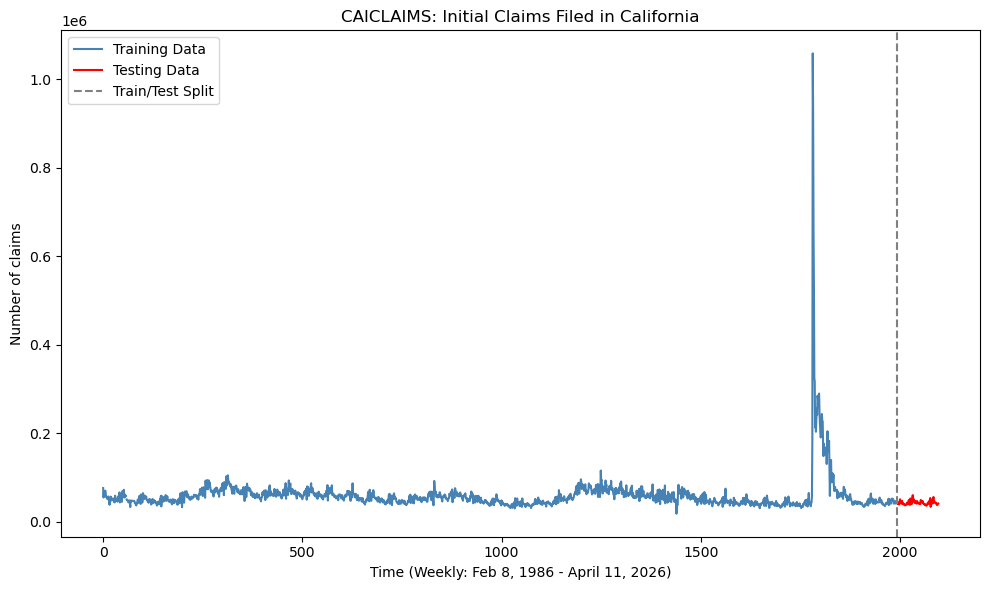

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(ttrain, ytrain_CA, label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Testing Data", color="red")
plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.title("CAICLAIMS: Initial Claims Filed in California")
plt.xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

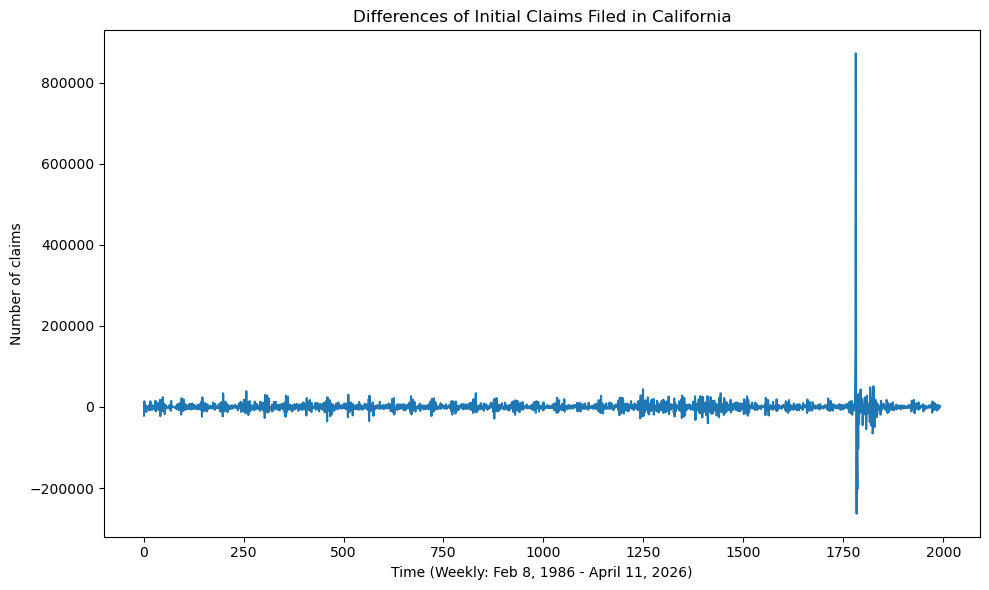

In [32]:
plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.title("Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

### **Design Matrix Construction**

In [33]:
def make_features_new(n, covid_start=1775, covid_end=1860, n_harmonics=3):
    t = np.arange(n)
    X = pd.DataFrame(index=np.arange(n))

    # Linear trend
    X["trend"] = t

    # Weekly data: yearly period is approximately 52 weeks
    for k in range(1, n_harmonics + 1):
        X[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)

    # COVID period indicator
    X["during_covid"] = ((t >= covid_start) & (t <= covid_end)).astype(int)

    return X

In [34]:
# Exog features through observed data only (for holdout RMSE / grid search)
X_CA_new = make_features_new(n=len(y_CA), covid_start=1775, covid_end=1860, n_harmonics=3)

Xtrain_CA_new = X_CA_new.iloc[:train_end]
Xtest_CA_new = X_CA_new.iloc[train_end : len(y_CA) + test_horizon]
Xtest_CA_new = Xtest_CA_new[Xtrain_CA_new.columns]

# Exog through observed data + future period (for extended future forecasts)
X_CA_new_extended = make_features_new(n=len(y_CA) + test_horizon, covid_start=1775, covid_end=1860, n_harmonics=3)

Xtrain_CA_new_extended = X_CA_new_extended.iloc[:train_end]
Xtest_CA_new_extended = X_CA_new_extended.iloc[train_end : len(y_CA) + test_horizon]
Xtest_CA_new_extended = Xtest_CA_new_extended[Xtrain_CA_new_extended.columns]

### **Parameter Selection (Grid Search)**

In [35]:
def rolling_cv_sarimax(
    y,
    X,
    order,
    initial_train_size=1500,
    horizon=52,
    step=26
):
    """
    Rolling-origin cross-validation for SARIMAX.

    At each split:
    - train on y[0:train_end]
    - forecast y[train_end:train_end+horizon]
    - compute RMSE
    """
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)

    rows = []

    split_points = range(initial_train_size, len(y) - horizon + 1, step)

    for train_end in split_points:
        test_start = train_end
        test_end = train_end + horizon - 1

        y_train = y.iloc[:train_end]
        y_test = y.iloc[test_start:test_start + horizon]

        X_train = X.iloc[:train_end]
        X_test = X.iloc[test_start:test_start + horizon]

        # Make sure columns match exactly
        X_test = X_test[X_train.columns]

        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            forecast = model.get_forecast(
                steps=horizon,
                exog=X_test
            )

            y_hat = forecast.predicted_mean
            y_hat.index = y_test.index

            rmse = np.sqrt(mean_squared_error(y_test, y_hat))

            rows.append({
                "train_end": train_end,
                "test_start": test_start,
                "test_end": test_end,
                "p": order[0],
                "d": order[1],
                "q": order[2],
                "RMSE": rmse,
                "AIC": model.aic,
                "BIC": model.bic,
                "status": "success"
            })

        except Exception as e:
            rows.append({
                "train_end": train_end,
                "test_start": test_start,
                "test_end": test_end,
                "p": order[0],
                "d": order[1],
                "q": order[2],
                "RMSE": np.nan,
                "AIC": np.nan,
                "BIC": np.nan,
                "status": "failed"
            })

    cv_results = pd.DataFrame(rows)

    mean_rmse = cv_results["RMSE"].mean(skipna=True)
    mean_aic = cv_results["AIC"].mean(skipna=True)
    mean_bic = cv_results["BIC"].mean(skipna=True)
    n_success = cv_results["RMSE"].notna().sum()

    return {
        "p": order[0],
        "d": order[1],
        "q": order[2],
        "CV_RMSE": mean_rmse,
        "CV_AIC": mean_aic,
        "CV_BIC": mean_bic,
        "n_success": n_success,
        "n_splits": len(cv_results)
    }

In [36]:
cache_path = "sarimax_cv_grid_results_CAICLAIMS.csv"

pmax, dmax, qmax = 8, 1, 6

param_grid = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

initial_train_size = 1500
horizon = 52
step = 26


def evaluate_order_cv(order):
    return rolling_cv_sarimax(
        y=ytrain_CA,
        X=Xtrain_CA_new,
        order=order,
        initial_train_size=initial_train_size,
        horizon=horizon,
        step=step
    )


if os.path.exists(cache_path):
    print(f"Loading cached grid search results from {cache_path}")
    results_sarimax_new_df = pd.read_csv(cache_path)

else:
    print("Running SARIMAX rolling-CV grid search...")

    results_sarimax_new = Parallel(n_jobs=-1, verbose=10)(
        delayed(evaluate_order_cv)(order) for order in param_grid
    )

    results_sarimax_new_df = pd.DataFrame(results_sarimax_new)

    # Save cache
    results_sarimax_new_df.to_csv(cache_path, index=False)
    print(f"Saved grid search results to {cache_path}")

Loading cached grid search results from sarimax_cv_grid_results_CAICLAIMS.csv


### **Best Models by Evaluation Metrics**

In [37]:
# Clean and sort results
results_sarimax_new_df = results_sarimax_new_df.dropna(subset=["CV_RMSE"])
results_sarimax_new_df = results_sarimax_new_df.sort_values("CV_RMSE").reset_index(drop=True)

print("Top SARIMAX models by rolling-origin CV RMSE:")
display(results_sarimax_new_df.head(10))

Top SARIMAX models by rolling-origin CV RMSE:


,p,d,q,CV_RMSE,CV_AIC,CV_BIC,n_success,n_splits
0,0,1,1,47721.191698,36487.862324,36542.247482,17,17
1,1,1,0,47926.816861,36735.036084,36789.427138,17,17
2,0,1,0,48223.247108,47973.689881,48022.641831,17,17
3,0,1,5,48328.247812,36323.282202,36399.388355,17,17
4,2,1,3,49011.995647,36370.451089,36446.573786,17,17
5,2,1,6,49366.557518,36279.757298,36372.161858,17,17
6,2,1,5,49519.955258,36301.148969,36388.127429,17,17
7,1,1,3,49558.867752,36366.239568,36436.924930,17,17
8,1,1,2,49656.046398,36396.732530,36461.987640,17,17
9,1,1,6,49682.865084,36297.877555,36384.846553,17,17


In [38]:
best_rmse_sarimax_new = results_sarimax_new_df.iloc[0]

best_p_new = int(best_rmse_sarimax_new['p'])
best_d_new = int(best_rmse_sarimax_new['d'])
best_q_new = int(best_rmse_sarimax_new['q'])

print(f"Best SARIMAX by rolling CV: SARIMAX({best_p_new}, {best_d_new}, {best_q_new})")
print(f"CV RMSE: {best_rmse_sarimax_new['CV_RMSE']:.3f}")
print(f"CV AIC: {best_rmse_sarimax_new['CV_AIC']:.3f}")
print(f"CV BIC: {best_rmse_sarimax_new['CV_BIC']:.3f}")
print(f"Successful CV splits: {int(best_rmse_sarimax_new['n_success'])} / {int(best_rmse_sarimax_new['n_splits'])}")

Best SARIMAX by rolling CV: SARIMAX(0, 1, 1)
CV RMSE: 47721.192
CV AIC: 36487.862
CV BIC: 36542.247
Successful CV splits: 17 / 17


### **Final Holdout Evaluation**

In [39]:
best_rmse_sarimax_model_new = SARIMAX(
    ytrain_CA,
    exog=Xtrain_CA_new_extended,
    order=(best_p_new, best_d_new, best_q_new),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(best_rmse_sarimax_model_new.summary())


best_rmse_sarimax_fcast_new = best_rmse_sarimax_model_new.get_forecast(
    steps=len(ytest_CA) + test_horizon,
    exog=Xtest_CA_new_extended
)

best_rmse_sarimax_yhat_new = best_rmse_sarimax_fcast_new.predicted_mean
best_rmse_sarimax_yhat_new.index = tpred
best_sarimax_rmse_new = np.sqrt(mean_squared_error(ytest_CA, best_rmse_sarimax_yhat_new.iloc[:len(ytest_CA)]))

print(f"\nFinal 2-year holdout RMSE for Best RMSE Rolling-CV SARIMAX({best_p_new:.0f}, {best_d_new:.0f}, {best_q_new:.0f}) Model: {best_sarimax_rmse_new}")

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:               SARIMAX(0, 1, 1)   Log Likelihood              -22801.817
Date:                Tue, 28 Apr 2026   AIC                          45623.634
Time:                        18:07:48   BIC                          45679.592
Sample:                             0   HQIC                         45644.186
                               - 1993                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
trend          -14.6707   1332.671     -0.011      0.991   -2626.658    2597.316
sin_1         2688.6486   1.67e+04      0.161      0.872   -3.01e+04    3.54e+04
cos_1         2317.0014   1.48e+04      0.15

### **Plotted SARIMAX Predictions**

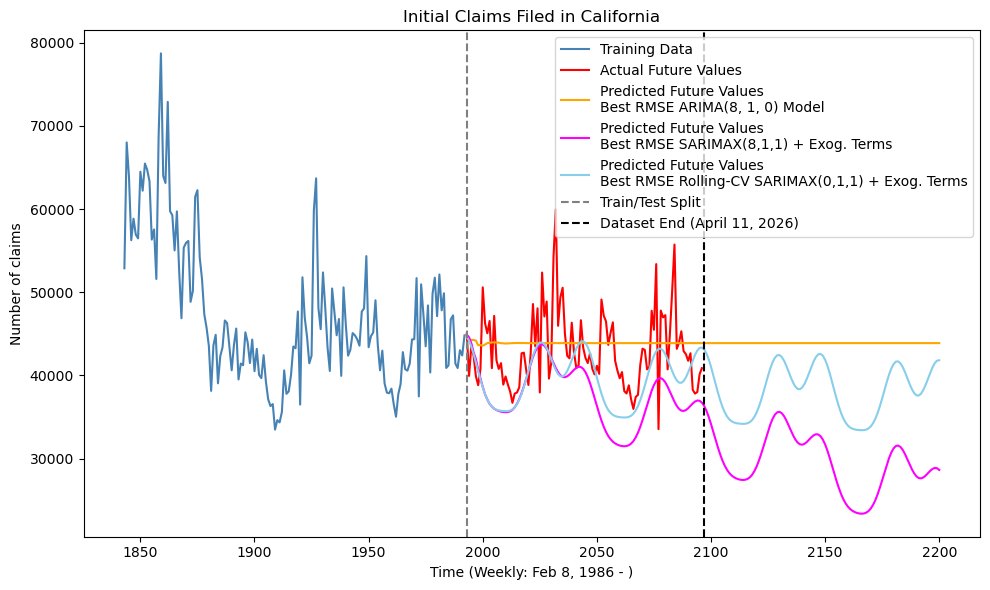

Root Mean Squared Error of Best RMSE ARMIA(8, 1, 0) Model: 4598.93312709685
Root Mean Squared Error of Best RMSE SARIMAX(8, 1, 1) Model: 7126.754229243658
Root Mean Squared Error of Best RMSE Rolling-CV SARIMAX(0, 1, 1) Model: 5810.691323773642


In [41]:
plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Future Values", color="red")

plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Predicted Future Values\nBest RMSE ARIMA({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model")
plt.plot(tpred, best_rmse_sarimax_yhat, color="magenta",
         label=f"Predicted Future Values\nBest RMSE SARIMAX({best_p},{best_d},{best_q}) + Exog. Terms")
plt.plot(tpred, best_rmse_sarimax_yhat_new, color="skyblue",
         label=f"Predicted Future Values\nBest RMSE Rolling-CV SARIMAX({best_p_new},{best_d_new},{best_q_new}) + Exog. Terms")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End (April 11, 2026)")

plt.title("Initial Claims Filed in California")
plt.xlabel("Time (Weekly: Feb 8, 1986 - )")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();


print(f"Root Mean Squared Error of Best RMSE ARMIA({best_rmse['p']:.0f}, {best_rmse['d']:.0f}, {best_rmse['q']:.0f}) Model: {best_rmse_rmse}")
print(f"Root Mean Squared Error of Best RMSE SARIMAX({best_p:.0f}, {best_d:.0f}, {best_q:.0f}) Model: {best_sarimax_rmse}")
print(f"Root Mean Squared Error of Best RMSE Rolling-CV SARIMAX({best_p_new:.0f}, {best_d_new:.0f}, {best_q_new:.0f}) Model: {best_sarimax_rmse_new}")